# Image processing notebook: From overlap corrected to transmission 

### 00 - exp 1XX acquisition 00

##  Initial settings

### Import libraries
Import all the required libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
%matplotlib inline

### Select directories
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI\200_processed\00_Overlap_corrected\exp302"

In [3]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302"

### Check folders to process

In [4]:
stack_dict = prep_stack_dict(src_dir)
for key in stack_dict.keys():
    print(key)

000_temp_00_m25_ob
001_temp_00_m25_prot
002_temp_01_m15_ob
003_temp_01_m15_prot
004_temp_02_m25_ob
005_temp_02_m25_prot
006_temp_03_p20_ob
007_temp_03_p20_prot
097_ob
098_ref_bb
099_ob


In [5]:
proc_folder1 = ['001_temp_00_m25_prot']
proc_folder2 = ['003_temp_01_m15_prot']
proc_folder3 = ['005_temp_02_m25_prot']
proc_folder4 = ['007_temp_03_p20_prot']
ref_folder = ['098_ref_bb']

## Process the reference folder (if not done before)
Or in case it is not previously saved.

In case the parameters and ref_dict are stored in the global variables, you can load them with : `%store -r "name given"`

It is **important** to not process the images fully before having played with them to find the right parameters (there is a notebook called playgound todo this)

In [6]:
#%store -r exp_param
ref_dir =  r"J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp300"
ref_dict = read_saved_dict (ref_dir, proc_folder = ['098_ref_bb'])

Reading Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  4.04it/s]


### Continue here if ref images are not done
if the ref images were done (with the same processing intended) then continue to section 3

In [7]:
#ref_param = {}
#nca_ref = [388, 10, 59, 488]

#add_to_dict(ref_param, ['threshold', 'ws_filter_size'], [0, 3])

In [8]:
#ref_seq =  [stack_averaging,
#            ob_roi_mod_dict,
#            scrubbing_correction_dict,
#            ws_filter,
#            outlier_removal,
#            SBKG_correction_dict]

In [9]:
#proc_folder = ref_folder
#BB_mask = get_img(src_dir + '/bb_mask_ref.fits')
#add_to_dict(ref_param,['BB_mask'], [BB_mask])

#ref_dict = full_processing (src_dir, dst_dir, proc_folder = ref_folder, sequence = ref_seq, 
#                 proc_parameters = ref_param, img_name = 'intensity', save = True)

## Gettinging an NCA

In [10]:
test_folder01 = ['001_temp_00_m25_prot']

img_dict01, _ = testing_mode_step (src_dir, proc_folder = test_folder01, keep_acq_numb = 1)

Reading Images: 100%|████████████████████████████| 3/3 [00:01<00:00,  2.22it/s]


In [11]:
img_batch01 = avg_frames_dict (img_dict01[test_folder01[0]], output_type = 'img')

In [12]:
# %load select_rois(img_batch01, list_rois = ['nca'])
nca = [96, 375, 327, 112]

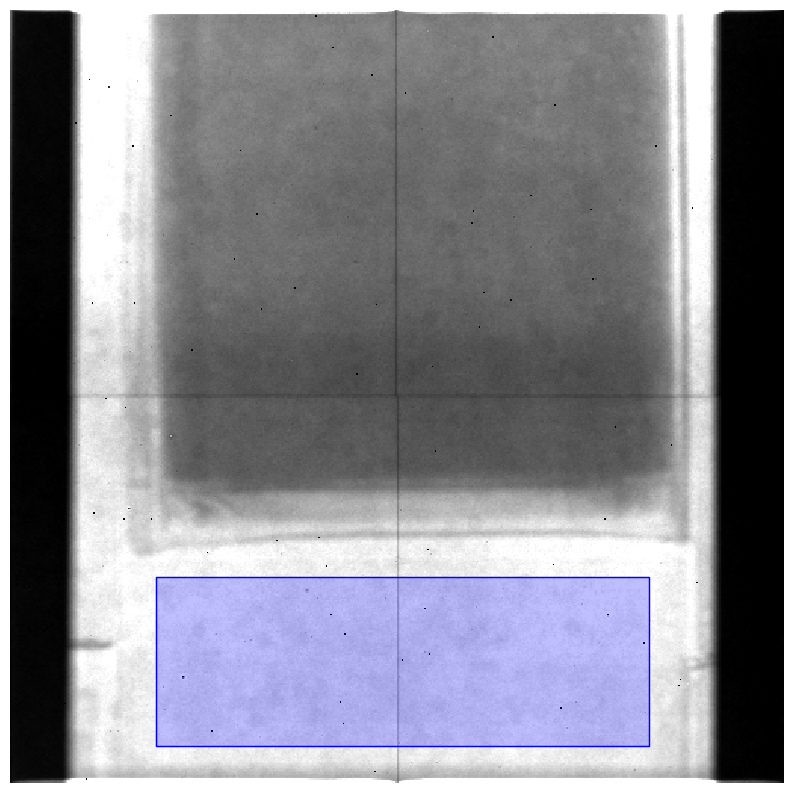

In [13]:
show_img(img_batch01[0], dr = [(nca, 'blue')], cmap='gray')

## Base parameters and Sequence

In [14]:
exp_param = {}

add_to_dict(exp_param, ['threshold', 'use_ref', 'ref_dict', 'ws_filter_size'], [0, True, ref_dict, 3])

In [15]:
exp_seq =  [outlier_removal,
            stack_averaging,
            ob_roi_mod_dict,
            ws_filter,
            scrubbing_correction_dict,
            SBKG_correction_dict,
            intensity_correction_dict,
            referencing_dict]

## Exp301 Processing

### Processing all

In [16]:
BB_mask = get_img(src_dir + '/bb_mask_prot.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder1, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|████████████████████████████| 3/3 [00:20<00:00,  6.79s/it]


Experiment 001_temp_00_m25_prot in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  3.27it/s]


Saving images as a single acquisition


Writing Images:   0%|                                    | 0/1 [00:00<?, ?it/s]

Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00000.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00001.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00002.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_fram

Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00032.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00033.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00034.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_fram

Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00069.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00070.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00071.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_fram

Writing Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  1.04it/s]

Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00101.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00102.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_framework\01_Transmission_results\exp302\001_temp_00_m25_prot\Acquisition_00\001_temp_00_m25_prot_transmission_00103.fits already exists. If you mean to replace it then use the argument "overwrite=True".
Could not write the destination image: File J:\700 Campaigns - internal\2021\PSI21_22NI_updated_fram

In [17]:
BB_mask = get_img(src_dir + '/bb_mask_prot.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder2, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|████████████████████████████| 3/3 [00:20<00:00,  6.68s/it]


Experiment 003_temp_01_m15_prot in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  3.41it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:03<00:00,  3.77s/it]


Total time: 420s


In [18]:
BB_mask = get_img(src_dir + '/bb_mask_prot.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder3, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|████████████████████████████| 3/3 [00:53<00:00, 17.82s/it]


Experiment 005_temp_02_m25_prot in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  3.38it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:03<00:00,  3.57s/it]


Total time: 486s


In [19]:
BB_mask = get_img(src_dir + '/bb_mask_prot.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder4, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|████████████████████████████| 2/2 [00:46<00:00, 23.30s/it]


Experiment 007_temp_03_p20_prot in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  3.41it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:03<00:00,  3.50s/it]


Total time: 421s
